In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


Scene 2 Changed! Waiting for stabilization...
Scene 2 Stabilized! Saving frame...
Scene 3 Changed! Waiting for stabilization...
Scene 3 Stabilized! Saving frame...
Scene 4 Changed! Waiting for stabilization...
Scene 4 Stabilized! Saving frame...
Total Scenes Detected: 4


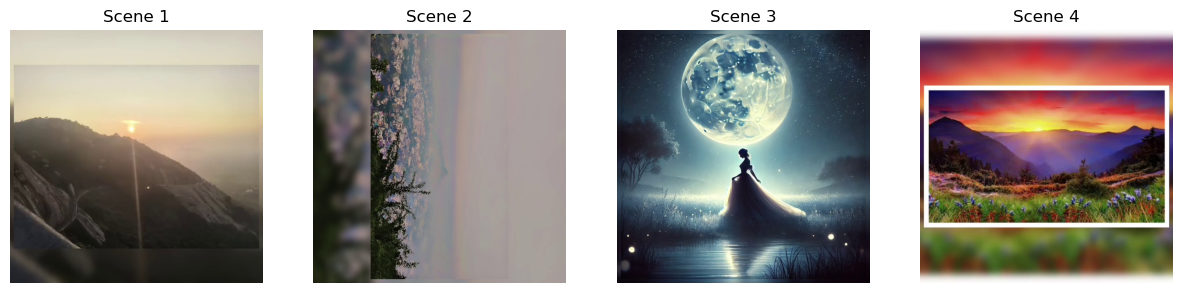

Processing Complete. All detected scenes displayed.


In [11]:
video_path = "scene.mp4"
cap = cv2.VideoCapture(video_path)
fgbg = cv2.createBackgroundSubtractorMOG2()
ret, frame = cap.read()
if not ret:
    print("Error: Couldn't read video")
    cap.release()
    exit()
scenes = [frame.copy()]

prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
prev_hist = cv2.calcHist([prev_gray], [0], None, [256], [0, 256])
cv2.normalize(prev_hist, prev_hist, 0, 1, cv2.NORM_MINMAX)

scene_change_detected = False

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    curr_hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    cv2.normalize(curr_hist, curr_hist, 0, 1, cv2.NORM_MINMAX)
    similarity = cv2.compareHist(prev_hist, curr_hist, cv2.HISTCMP_CORREL)
    fg_mask = fgbg.apply(frame)
    change_ratio = np.count_nonzero(fg_mask) / fg_mask.size
    if similarity < 0.5 and change_ratio > 0.3 and not scene_change_detected:
        print(f"Scene {len(scenes) + 1} Changed! Waiting for stabilization...")
        scene_change_detected = True
    elif scene_change_detected and similarity > 0.9:
        print(f"Scene {len(scenes) + 1} Stabilized! Saving frame...")
        scenes.append(frame.copy())
        scene_change_detected = False  # Reset flag
    prev_hist = curr_hist.copy()

cap.release()
print(f"Total Scenes Detected: {len(scenes)}")
plt.figure(figsize=(15, 5))

for i, scene in enumerate(scenes):
    plt.subplot(1, len(scenes), i + 1)
    plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    plt.title(f"Scene {i + 1}")
    plt.axis("off")

plt.show()
print("Processing Complete. All detected scenes displayed.")
